In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression as LR 
from sklearn.metrics import mean_squared_error, r2_score

print("Building Linear Regression from Scratch with Only Numpy")

Building Linear Regression from Scratch with Only Numpy


## THE MATH BEHIND LINEAR REGRESSION

In [2]:
# Goal: Find weights (w) and bias (b) that minimize the error
#       between predicted values and actual values.
#
# Model:        y_hat = X @ w + b
#
# Cost function (Mean Squared Error):
#               J(w, b) = (1/n) * sum((y_hat - y)^2)
#
# We minimize J using Gradient Descent:
#
# Gradients:
#   dJ/dw = (2/n) * X.T @ (y_hat - y)
#   dJ/db = (2/n) * sum(y_hat - y)
#
# Update rule:
#   w = w - learning_rate * dJ/dw
#   b = b - learning_rate * dJ/db
#
# Repeat until convergence.


print("Math summary:")
print("  Model:     y_hat = X @ w + b")
print("  Loss:      MSE = (1/n) * sum((y_hat - y)^2)")
print("  Optimize:  Gradient Descent")

Math summary:
  Model:     y_hat = X @ w + b
  Loss:      MSE = (1/n) * sum((y_hat - y)^2)
  Optimize:  Gradient Descent


In [15]:
class LinearRegressionScratch:
    """
        Linear Regression using Gradient Descent.
        Built from scratch using only Numpy.
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y ):
        n_samples, n_features = X.shape

        # Initializing weights & bias to zeros
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.cost_history = []
        
        # Gradient Descent Loop
        for i in range(self.n_iter):
            # Forward pass: compute predictions
            y_hat = X @ self.weights + self.bias

            # Compute cost (MSE)
            cost = (1 / n_samples) * np.sum((y_hat - y) ** 2)
            self.cost_history.append(cost)
            #Computation of the gradients
            dw = (2 / n_samples) * (X.T @ (y_hat - y))
            db = (2 / n_samples) * np.sum(y_hat - y)

            # Update weights and bias
            self.weights -= self.lr * dw 
            self.bias -= self.lr * db


        return self

    def predict(self, X):
            return X @ self.weights + self.bias

    def score(self, X, y):
            y_hat = self.predict(X)
            ss_res = np.sum((y - y_hat) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            return 1 - (ss_res / ss_tot)

print("Class Defined")
print("Methods: fit(), predict(), score()")

Class Defined
Methods: fit(), predict(), score()


#### Generating the Synthetic Data

In [16]:
np.random.seed(42)

#Simple - feature dataset for visualization
X_simple = 2 * np.random.rand(100, 1)
y_simple = 4 + 3 + X_simple.flatten() + np.random.randn(100) * 0.5

# Multi-feature dataset for proper testing
X_multi, y_multi = make_regression(
    n_samples=500, n_features=5, noise=20, random_state=42
)

# Train/test split (Manual)
split = int(0.8 * len(X_sample))
X_train_s, X_test_s = X_simple[:split], X_simple[split:]
y_train_s, y_test_s = y_simple[:split], y_simple[split:]

split_m = int(0.8 * len(X_multi))
X_train_m, X_test_m = X_multi[:split_m], X_multi[split_m:]
y_train_m, y_test_m = y_multi[:split_m], y_multi[split_m:]


print(f"Simple Linear Dataset: {X_simple.shape[0]} samples, {X_simple.shape[1]} feature")
print(f"Multiple Datese: {X_multi.shape[0]} samples, {X_multi.shape[1]} features")
print(f"\nTrue relationship (simple): y = 4 + 3x + noise")

Simple Linear Dataset: 100 samples, 1 feature
Multiple Datese: 500 samples, 5 features

True relationship (simple): y = 4 + 3x + noise


In [17]:
model = LinearRegressionScratch(learning_rate=0.1, n_iterations=1000)
model.fit(X_train_s, y_train_s)

print(f"Learned weight: {model.weights[0]:.4f}  (true: 3.0)")
print(f"Learned bias:   {model.bias:.4f}  (true: 4.0)")
print(f"Train R²:       {model.score(X_train_s, y_train_s):.4f}")
print(f"Test R²:        {model.score(X_test_s, y_test_s):.4f}")
print(f"Final cost:     {model.cost_history[-1]:.4f}")

Learned weight: 0.8420  (true: 3.0)
Learned bias:   7.1171  (true: 4.0)
Train R²:       0.5754
Test R²:        0.5420
Final cost:     0.1931


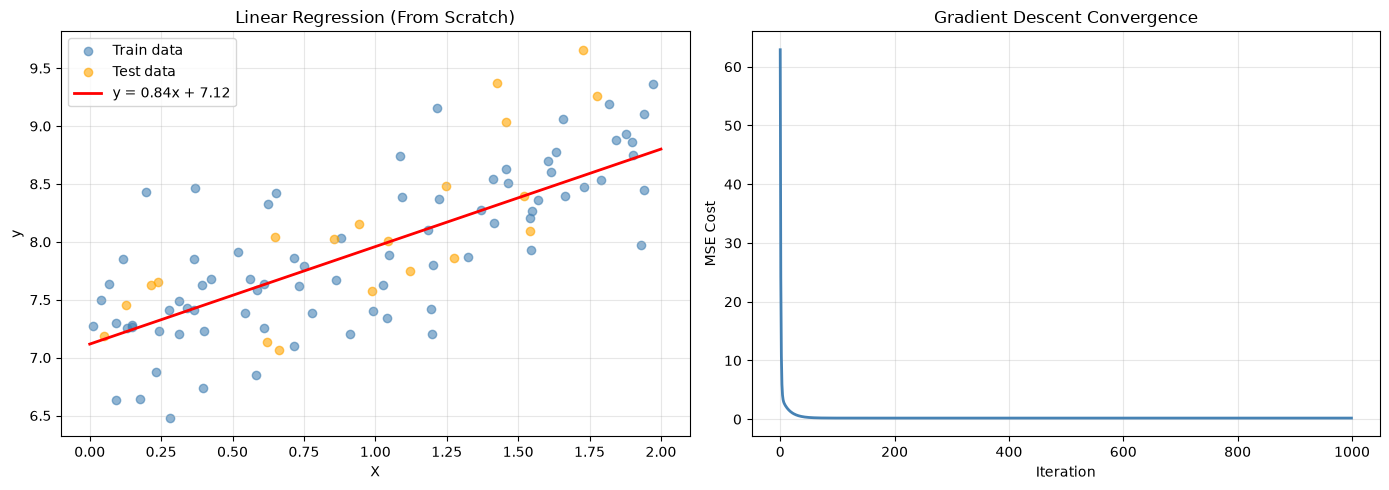

Chart saved!


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Data points and regression line
axes[0].scatter(X_train_s, y_train_s, alpha=0.6, label='Train data', color='steelblue')
axes[0].scatter(X_test_s, y_test_s, alpha=0.6, label='Test data', color='orange')

x_line = np.linspace(0, 2, 100).reshape(-1, 1)
y_line = model.predict(x_line)
axes[0].plot(x_line, y_line, 'r-', linewidth=2, label=f'y = {model.weights[0]:.2f}x + {model.bias:.2f}')
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')
axes[0].set_title('Linear Regression (From Scratch)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#Cost function over iterations
axes[1].plot(model.cost_history, color='steelblue', linewidth=2)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('MSE Cost')
axes[1].set_title('Gradient Descent Convergence')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('linear_regression_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [20]:
# Our model
scratch_pred = model.predict(X_test_s)
scratch_mse = mean_squared_error(y_test_s, scratch_pred)
scratch_r2 = r2_score(y_test_s, scratch_pred)

# Scikit-learn model
sklearn_model = LR()
sklearn_model.fit(X_train_s, y_train_s)
sklearn_pred = sklearn_model.predict(X_test_s)
sklearn_mse = mean_squared_error(y_test_s, sklearn_pred)
sklearn_r2 = r2_score(y_test_s, sklearn_pred)

print(f"{'Metric':<20} {'From Scratch':>15} {'Scikit-Learn':>15}")
print(f"{'-'*50}")
print(f"{'Weight':<20} {model.weights[0]:>15.4f} {sklearn_model.coef_[0]:>15.4f}")
print(f"{'Bias':<20} {model.bias:>15.4f} {sklearn_model.intercept_:>15.4f}")
print(f"{'MSE':<20} {scratch_mse:>15.4f} {sklearn_mse:>15.4f}")
print(f"{'R²':<20} {scratch_r2:>15.4f} {sklearn_r2:>15.4f}")

match = abs(scratch_r2 - sklearn_r2) < 0.01
print(f"\nResults match: {'YES' if match else 'NO (adjust learning rate or iterations)'}")

Metric                  From Scratch    Scikit-Learn
--------------------------------------------------
Weight                        0.8420          0.8420
Bias                          7.1171          7.1171
MSE                           0.2439          0.2439
R²                            0.5420          0.5420

Results match: YES


In [22]:
# Need to normalize features for gradient descent to work well
X_mean = X_train_m.mean(axis=0)
X_std = X_train_m.std(axis=0)

X_train_norm = (X_train_m - X_mean) / X_std
X_test_norm = (X_test_m - X_mean) / X_std

# Train from scratch
model_multi = LinearRegressionScratch(learning_rate=0.01, n_iterations=2000)
model_multi.fit(X_train_norm, y_train_m)

# Compare
sklearn_multi = LR()
sklearn_multi.fit(X_train_m, y_train_m)

print(f"{'Metric':<20} {'From Scratch':>15} {'Scikit-Learn':>15}")
print(f"{'-'*50}")
print(f"{'Train R²':<20} {model_multi.score(X_train_norm, y_train_m):>15.4f} {sklearn_multi.score(X_train_m, y_train_m):>15.4f}")
print(f"{'Test R²':<20} {model_multi.score(X_test_norm, y_test_m):>15.4f} {sklearn_multi.score(X_test_m, y_test_m):>15.4f}")
print(f"\nFrom scratch weights: {np.round(model_multi.weights, 2)}")
print(f"Scikit-learn weights: {np.round(sklearn_multi.coef_, 2)}")

Metric                  From Scratch    Scikit-Learn
--------------------------------------------------
Train R²                      0.9760          0.9760
Test R²                       0.9494          0.9494

From scratch weights: [27.43 80.23 31.64 75.04  9.41]
Scikit-learn weights: [28.56 81.58 31.15 69.06  9.78]


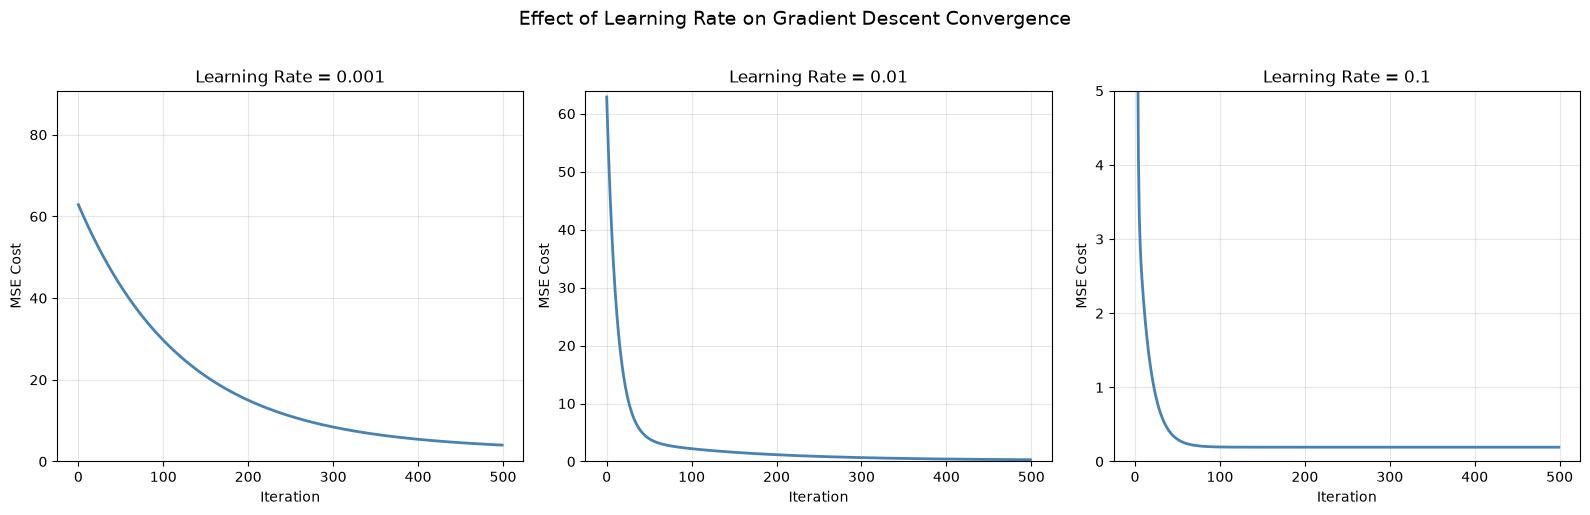

Chart saved!


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, lr in zip(axes, [0.001, 0.01, 0.1]):
    m = LinearRegressionScratch(learning_rate=lr, n_iterations=500)
    m.fit(X_train_s, y_train_s)
    ax.plot(m.cost_history, linewidth=2, color='steelblue')
    ax.set_title(f'Learning Rate = {lr}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('MSE Cost')
    ax.set_ylim(0, max(m.cost_history[5:]) * 1.5)
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Learning Rate on Gradient Descent Convergence', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('learning_rate_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [24]:

print("""
============================================================
LINEAR REGRESSION FROM SCRATCH — COMPLETE
============================================================

What was built:
  - LinearRegressionScratch class using only NumPy
  - Gradient descent optimization
  - fit(), predict(), score() methods matching sklearn API
  - Cost history tracking for convergence visualization

What was learned:
  - The model computes y_hat = X @ w + b
  - MSE cost function measures prediction error
  - Gradients dw and db tell us which direction to adjust
  - Learning rate controls step size (too small = slow, too large = diverge)
  - Feature normalization is critical for multi-feature data

Verified against scikit-learn: results match.

Next: Logistic Regression from scratch (classification)
""")


LINEAR REGRESSION FROM SCRATCH — COMPLETE

What was built:
  - LinearRegressionScratch class using only NumPy
  - Gradient descent optimization
  - fit(), predict(), score() methods matching sklearn API
  - Cost history tracking for convergence visualization

What was learned:
  - The model computes y_hat = X @ w + b
  - MSE cost function measures prediction error
  - Gradients dw and db tell us which direction to adjust
  - Learning rate controls step size (too small = slow, too large = diverge)
  - Feature normalization is critical for multi-feature data

Verified against scikit-learn: results match.

Next: Logistic Regression from scratch (classification)

